<details>
<summary><b>Info</b></summary>

**Last Execution:** 2026-08-05

| Package | Version |
|---------|---------|
| **nnsight** | **0.8** |
| Python | 3.12.13 |
| torch | 2.13.0+cu126 |
| diffusers | 0.39.0 |

</details>

# Concept Attention

## Introduction

🖼️ Where in a generated image does a *concept* live? Not "where is the cat" as an object
detector would answer it, but: which patches did the model itself treat as cat-ish while it was
drawing?

**ConceptAttention** answers this with a trick that is very neat once you see it. A diffusion
transformer like FLUX runs two streams through joint attention — the text (encoder) stream and
the image stream. The method adds a **third stream of "concept" tokens**: encode words like
`cat`, `grass`, `sky`, `tree` through the same text encoder, append them to the encoder
sequence, and then install an attention mask that makes them **one-way passengers**:

- nothing may attend *to* the concepts, so the image the model produces is unchanged;
- the concepts may attend *to the image*, so they accumulate information about it.

The concepts ride along through the whole denoising process, seeing everything and influencing
nothing. Afterwards, the inner product between each image patch's attention output and each
concept's attention output — softmaxed across concepts — is a per-concept spatial heatmap.

The appeal is that nothing is trained and nothing is approximated. The heatmaps come out of the
model's own attention geometry, on the same forward pass that produced the image.

📗 [*ConceptAttention: Diffusion Transformers Learn Highly Interpretable Features*](https://arxiv.org/abs/2502.04320)
(Helbling, Meral, Hoover, Yilmaz, Chau, CVPR 2025). Adapted from the CVPR 2026 HOW workshop
[companion code](https://github.com/JadenFiotto-Kaufman/CVPR2026-HOW).

## Setup

If using Colab, install NNsight and diffusers:
```
!pip install -U nnsight diffusers
```

This runs `FLUX.2-klein-4B` locally — about 24 GB of weights and roughly 30 GB of GPU memory at
1024×1024. On a smaller card, drop to `width=height=512`.

In [1]:
try:
    import google.colab
    is_colab = True
except ImportError:
    is_colab = False

if is_colab:
    !pip install -U nnsight diffusers

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import nnsight
from nnsight import DiffusionModel

`torch_dtype`, not `dtype` — this keyword is handed to `diffusers`, which still uses the older
spelling and silently ignores the new one.

In [3]:
flux = DiffusionModel(
    "black-forest-labs/FLUX.2-klein-4B",
    torch_dtype=torch.bfloat16,
    dispatch=True,
    device_map="cuda",
)
flux.pipeline.set_progress_bar_config(disable=True)

PROMPT = "A cat in a park on the grass by a tree"
CONCEPTS = ["cat", "grass", "sky", "tree"]
STEPS = 4
SIZE = 1024
SEED = 0

n_blocks = len(flux.transformer.transformer_blocks)
print(f"{n_blocks} joint transformer blocks")

5 joint transformer blocks


## Encoding the concepts

The concepts go through the *same* text encoder as the prompt, so they land in the same space
as the encoder stream they are about to join.

One fiddly detail: FLUX.2's text encoder is Qwen3, which wraps every input in a chat template.
Encoding the single word `"cat"` produces a 512-token padded sequence in which the actual word
sits at **position 3** (positions 0–2 are `<|im_start|>user\n`). We take that one row.

In [4]:
CONCEPT_POSITION = 3

pipeline = flux.pipeline
device = next(pipeline.text_encoder.parameters()).device

def encode(text):
    out = pipeline.encode_prompt(prompt=text, device=device, num_images_per_prompt=1)
    return out[0] if isinstance(out, tuple) else out

prompt_embeds = encode(PROMPT)
concept_embeds = torch.cat(
    [encode(concept)[:, CONCEPT_POSITION:CONCEPT_POSITION + 1, :] for concept in CONCEPTS],
    dim=1,
)

# The encoder stream the transformer will actually receive: prompt, then concepts.
encoder_embeds = torch.cat([prompt_embeds, concept_embeds.to(prompt_embeds.dtype)], dim=1)

L_txt = prompt_embeds.shape[1]
L_c = concept_embeds.shape[1]
L_img = (SIZE // 16) ** 2
GRID = SIZE // 16

print(f"prompt {L_txt} + concepts {L_c} = encoder sequence {encoder_embeds.shape[1]}")
print(f"image patches: {L_img} ({GRID} x {GRID})")

prompt 512 + concepts 4 = encoder sequence 516
image patches: 4096 (64 x 64)


## The mask is the method

Joint attention runs over the concatenated sequence `[prompt | concepts | image]`. Three blocks
of the mask get switched off, and each one buys something specific:

In [5]:
allow = torch.ones(L_txt + L_c + L_img, L_txt + L_c + L_img, dtype=torch.bool)
c_start, c_end = L_txt, L_txt + L_c

allow[:c_start, c_start:c_end] = False   # prompt  -> concept   : keeps the prompt stream clean
allow[c_end:, c_start:c_end] = False     # image   -> concept   : keeps the *image* unchanged
allow[c_start:c_end, :c_start] = False   # concept -> prompt    : concepts see only image + self

print(f"mask {tuple(allow.shape)}, {(~allow).sum().item():,} blocked pairs")

mask (4612, 4612), 20,480 blocked pairs


The middle line is the one that makes the method honest. Without it the concept tokens would
feed back into the image and we would be interpreting a picture we had ourselves altered.

FLUX.2 also assigns RoPE positions to every encoder row, which would give the concepts
positions after the prompt. The paper specifies `concept_pe = 0`, so we build the position ids
ourselves with the concept rows zeroed and install them during the trace.

In [6]:
text_ids = torch.zeros(1, L_txt + L_c, 4, dtype=torch.long, device=device)
text_ids[:, :L_txt, 3] = torch.arange(L_txt, device=device)

## The trace

Everything happens on one generation. Per denoising step we overwrite the transformer's
`txt_ids` keyword argument, then walk the joint blocks and record, for each one, the inner
product between the image stream's attention output and the concepts'.

Two ordering constraints worth knowing:

- **Bound the loop.** `tracer.iter[:STEPS]`, not `tracer.iter[:]`. An unbounded loop over-runs
  and everything after it — including `tracer.result.save()` — is dropped.
- **Read in forward order.** In FLUX.2's attention processor `to_add_out` (encoder) fires
  *before* `to_out[0]` (image), so they must be accessed in that order or nnsight raises
  `OutOfOrderError`. FLUX.1 is the other way round.

We keep the scores per (step, block) rather than accumulating, so we can choose which to
average over afterwards without regenerating.

In [7]:
with flux.generate(
    prompt_embeds=encoder_embeds,
    attention_kwargs={"attention_mask": allow},
    width=SIZE, height=SIZE,
    num_inference_steps=STEPS,
    seed=SEED,
) as tracer:
    per_step = nnsight.save([])

    for _step in tracer.iter[:STEPS]:
        # Install the zero-position concept ids for this step.
        keyword_args = dict(flux.transformer.inputs[1])
        keyword_args["txt_ids"] = text_ids
        flux.transformer.inputs = (flux.transformer.inputs[0], keyword_args)

        per_block = []
        for block in flux.transformer.transformer_blocks:
            encoder_attention = block.attn.to_add_out.input   # [1, L_txt + L_c, D]
            image_attention = block.attn.to_out[0].input      # [1, L_img,       D]
            concept_attention = encoder_attention[:, L_txt:]  # [1, L_c,         D]

            scores = torch.einsum(
                "bpd,bcd->bcp", image_attention.float(), concept_attention.float()
            ).softmax(dim=-2)                                 # normalize across concepts
            per_block.append(scores.cpu())                    # keep the GPU free
        per_step.append(per_block)

    result = tracer.result.save()

scores = torch.stack([torch.stack(block) for block in per_step])   # [step, block, 1, C, P]
image = result.images[0]
print("scores per (step, block):", tuple(scores.shape))

Guidance scale 4.0 is ignored for step-wise distilled models.


scores per (step, block): (4, 5, 1, 4, 4096)


## The heatmaps

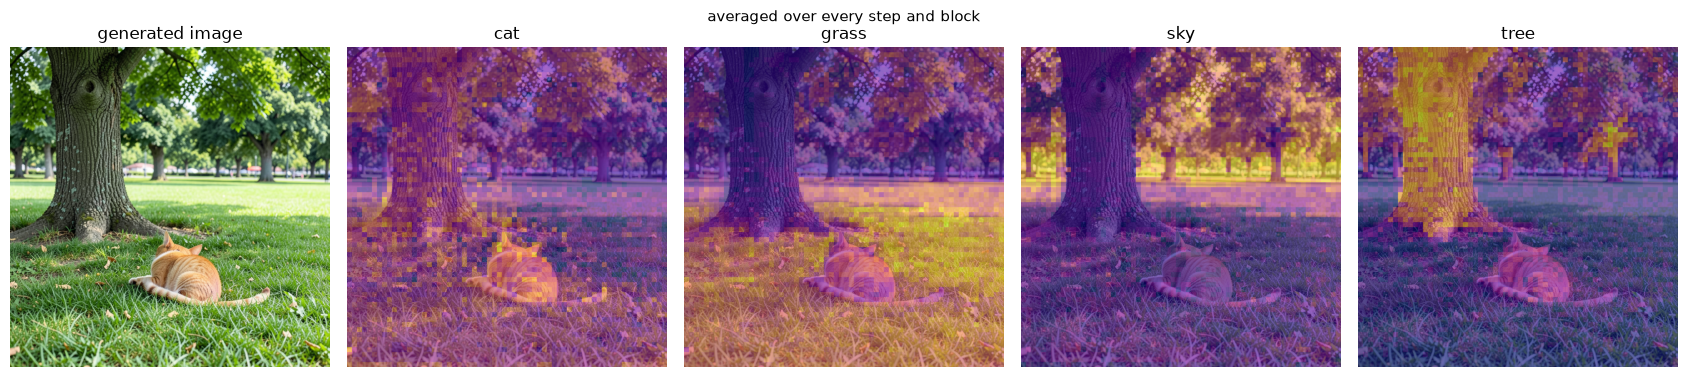

In [8]:
def heatmaps_from(selected):
    """Average [step, block, 1, C, P] scores down to one [C, GRID, GRID] map per concept."""
    return selected.mean((0, 1))[0].unflatten(-1, (GRID, GRID)).numpy()

def show(maps, title):
    fig, axes = plt.subplots(1, len(CONCEPTS) + 1, figsize=(3.4 * (len(CONCEPTS) + 1), 3.8))
    axes[0].imshow(image)
    axes[0].set_title("generated image")
    axes[0].axis("off")
    upscale = SIZE // GRID
    for ax, concept, heatmap in zip(axes[1:], CONCEPTS, maps):
        ax.imshow(image)
        ax.imshow(np.kron(heatmap, np.ones((upscale, upscale))), cmap="plasma", alpha=0.6)
        ax.set_title(concept)
        ax.axis("off")
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()

show(heatmaps_from(scores), "averaged over every step and block")

`tree` sits on the trunk, `grass` on the lawn, `sky` on the bright band above the horizon. All
three are localised to the right region of an image the model drew itself, from four words that
never influenced it.

`cat` is the weak one — it finds the animal but also lights up the trunk. Worth saying plainly
rather than cropping: this is a 4-billion-parameter distilled model running four denoising
steps through five joint blocks, and the paper's results use a larger model and more of both.

## Choosing steps and blocks

Averaging everything is the blunt option. The paper selects layers and timesteps, on the
grounds that early steps are still laying out composition and early blocks have not yet
separated the streams.

Because we kept the scores per (step, block), we can test that without regenerating. A crude
but serviceable measure of "is this heatmap actually pointing somewhere": the mean of the
brightest 5% of patches over the mean of all of them.

In [9]:
def sharpness(heatmap):
    flat = heatmap.flatten()
    k = max(1, int(0.05 * flat.size))
    return float(np.sort(flat)[-k:].mean() / flat.mean())

subsets = {
    "all steps and blocks": scores,
    "last 3 blocks": scores[:, 2:],
    "skip the first step": scores[1:],
    "last 3 blocks, skip first step": scores[1:, 2:],
}

print(f"{'subset':<32}" + "".join(f"{c:>9}" for c in CONCEPTS))
for name, subset in subsets.items():
    maps = heatmaps_from(subset)
    print(f"{name:<32}" + "".join(f"{sharpness(m):>9.2f}" for m in maps))

subset                                cat    grass      sky     tree
all steps and blocks                 1.47     2.10     3.16     3.96
last 3 blocks                        2.00     2.61     3.10     3.59
skip the first step                  1.55     2.24     3.90     5.10
last 3 blocks, skip first step       1.94     2.99     3.98     4.70


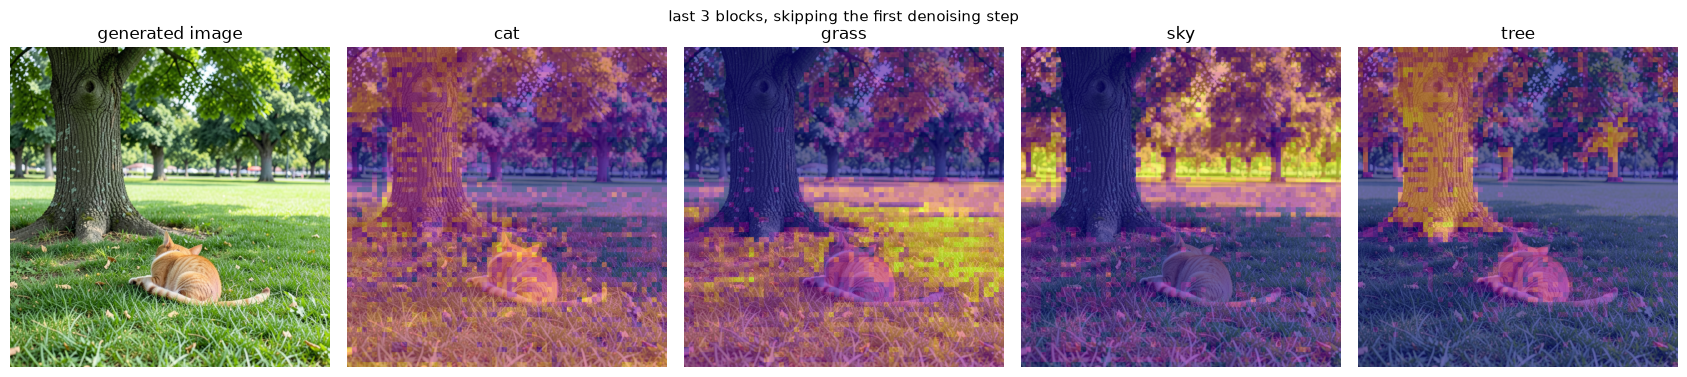

In [10]:
show(heatmaps_from(scores[1:, 2:]), "last 3 blocks, skipping the first denoising step")

Every concept sharpens under selection — `grass` by 42% and `cat` by 32%, which are the two
that needed it most. And no single subset wins outright: `tree` is sharpest with only the first
step dropped (5.10), while `cat` needs the block selection to improve at all. That per-concept
variation is exactly why the method is specified with layer and timestep indices rather than a
flat average over everything.

## Does the image really stay unchanged?

The whole argument rests on the claim that the concept tokens are invisible to the image
stream. That is a checkable claim, so let us check it rather than assume it: generate the same
prompt and seed with no concepts at all, and compare.

In [11]:
plain = flux.generate(
    prompt_embeds=prompt_embeds, width=SIZE, height=SIZE,
    num_inference_steps=STEPS, seed=SEED,
).images[0]

# Control: the same run with the image -> concept block of the mask *removed*.
leaky_mask = allow.clone()
leaky_mask[c_end:, c_start:c_end] = True
leaked = flux.generate(
    prompt_embeds=encoder_embeds, attention_kwargs={"attention_mask": leaky_mask},
    width=SIZE, height=SIZE, num_inference_steps=STEPS, seed=SEED,
).images[0]

as_array = lambda img: np.asarray(img).astype(int)
print(f"masked   vs no concepts: mean |diff| = {np.abs(as_array(image) - as_array(plain)).mean():.3f}")
print(f"unmasked vs no concepts: mean |diff| = {np.abs(as_array(leaked) - as_array(plain)).mean():.3f}")

Guidance scale 4.0 is ignored for step-wise distilled models.


Guidance scale 4.0 is ignored for step-wise distilled models.


masked   vs no concepts: mean |diff| = 0.883
unmasked vs no concepts: mean |diff| = 7.668


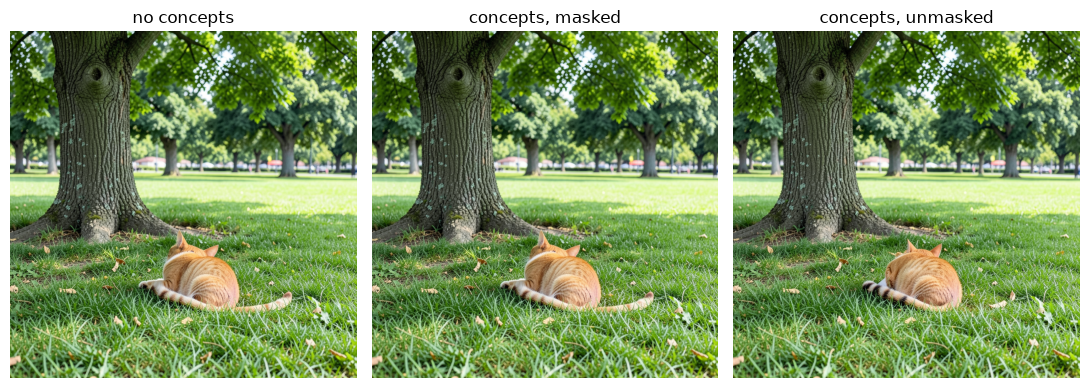

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, img, title in zip(axes, [plain, image, leaked],
                          ["no concepts", "concepts, masked", "concepts, unmasked"]):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

With the mask in place the image is *nearly* identical to the no-concepts run — the residual is
bfloat16 reassociation noise, since a longer sequence changes how the attention kernels tile,
not a semantic change. Remove one line of the mask and the difference is an order of magnitude
larger and visible: the concepts start steering the picture.

That gap is the evidence that the masking works. Without this control, "the concepts don't
affect the image" would just be a claim about code we wrote.

## Conclusion

🎉 Four extra tokens, one attention mask, and an inner product produce per-concept spatial maps
of a generated image — with no training, no probe, and no second forward pass.

In `nnsight` the whole method is three interventions on one `generate` trace: overwrite a
keyword argument per step, read two module inputs per block, and reduce them before they leave
the GPU. The parts that were fiddly are the model's, not the library's — Qwen3's chat template
offset, FLUX.2's RoPE position ids, and the order the attention processor calls its projections.

Related: [Cross-Attention Ablation](../tutorials/vision/cross-attention-ablation.ipynb) for
intervening on a diffusion model rather than reading it,
[The Logit Lens Over Image Tokens](vlm-logit-lens.ipynb) for the same question on a VLM, and
[Multiple Token Generation](../../features/4_multiple_token.ipynb) for `tracer.iter`.

## References

- Helbling, Meral, Hoover, Yilmaz, Chau, [*ConceptAttention: Diffusion Transformers Learn Highly Interpretable Features*](https://arxiv.org/abs/2502.04320), CVPR 2025
- Esser et al., [*Scaling Rectified Flow Transformers for High-Resolution Image Synthesis*](https://arxiv.org/abs/2403.03206) — the joint-attention DiT the method builds on
- CVPR 2026 HOW workshop companion code — [github.com/JadenFiotto-Kaufman/CVPR2026-HOW](https://github.com/JadenFiotto-Kaufman/CVPR2026-HOW)